  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  161k  100  161k    0     0   186k      0 --:--:-- --:--:-- --:--:--  186k


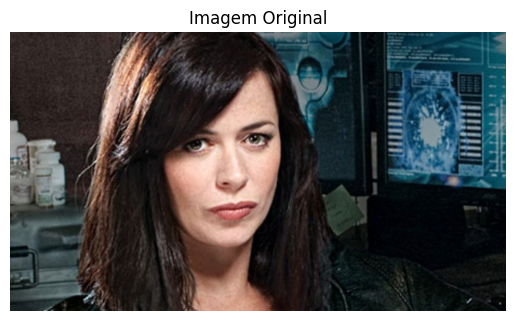

26-03-10 18:00:06 - Searching teste.jpeg in 1 length datastore
26-03-10 18:00:06 - find function duration 1.8614726066589355 seconds


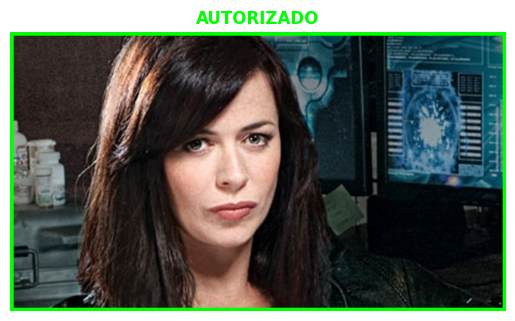

In [3]:
# 1. Instalando e importando de bibliotecas
!pip install deepface opencv-python matplotlib

import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace
import os

# 2. Configurando diretórios e Download da imagem externa
diretorio_bd = 'autorizados/'
caminho_teste = 'teste.jpeg'

# Garantindo que a pasta autorizados/ exista para não gerar erro na verificação
os.makedirs(diretorio_bd, exist_ok=True)

# Baixando a imagem de teste da internet usando o curl
!curl -L "https://i.imgur.com/Bt2Vyt2.jpeg" -o teste.jpeg

# 3. Lendo e exibindo da imagem
# Lê a imagem de teste e converte de BGR para RGB antes de exibir
img = cv2.imread(caminho_teste)

if img is None:
    print("Erro: Não foi possível carregar a imagem. Verifique se a URL está correta.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Inspeciona visualmente a imagem antes da classificação usando plt.imshow
    plt.imshow(img_rgb)
    plt.title("Imagem Original")
    plt.axis('off')
    plt.show()

    # 4. Busca e comparação facial
    try:
        # Executa a função DeepFace.find() comparando a imagem de teste com o banco de imagens
        resultados = DeepFace.find(img_path=caminho_teste, db_path=diretorio_bd, enforce_detection=False)

        # Verifica se houve alguma correspondência retornada na lista de DataFrames
        houve_correspondencia = len(resultados) > 0 and not resultados[0].empty
    except Exception as e:
        houve_correspondencia = False
        print(f"Aviso durante a verificação: {e}")

    # 5. Classificação e decisão
    # Define o texto e a cor de acordo com o resultado utilizando estrutura condicional if
    if houve_correspondencia:
        status = "AUTORIZADO"
        cor = (0, 255, 0) # Verde em RGB
    else:
        status = "NÃO AUTORIZADO"
        cor = (255, 0, 0) # Vermelho em RGB

    # 6. Feedback visual
    # Desenha uma moldura colorida na imagem conforme o resultado
    espessura_linha = 15
    altura, largura, _ = img_rgb.shape

    # Aplicação do cv2.rectangle desenha a moldura
    cv2.rectangle(img_rgb, (0, 0), (largura, altura), cor, espessura_linha)

    # Exibe com título utilizando plt.imshow
    plt.imshow(img_rgb)
    plt.title(status, color=[c/255 for c in cor], fontweight='bold')
    plt.axis('off')
    plt.show()